### Example: Movie Recommendation System
If you use simple keyword matching:
- Movie A: "A space adventure with aliens"  
- Movie B: "A story about extraterrestrial life"  

Keyword matching may **fail** because the keywords differ ("space" vs "extraterrestrial") even though the movies are similar in meaning.  
Conversely, movies with the **same keyword** may not be similar:
- Movie C: "A space documentary"  
- Movie D: "A space-themed romantic comedy"  

A **better approach** is to **compare plots using semantic search**: generate embeddings for movie plots and find movies with similar vector representations.

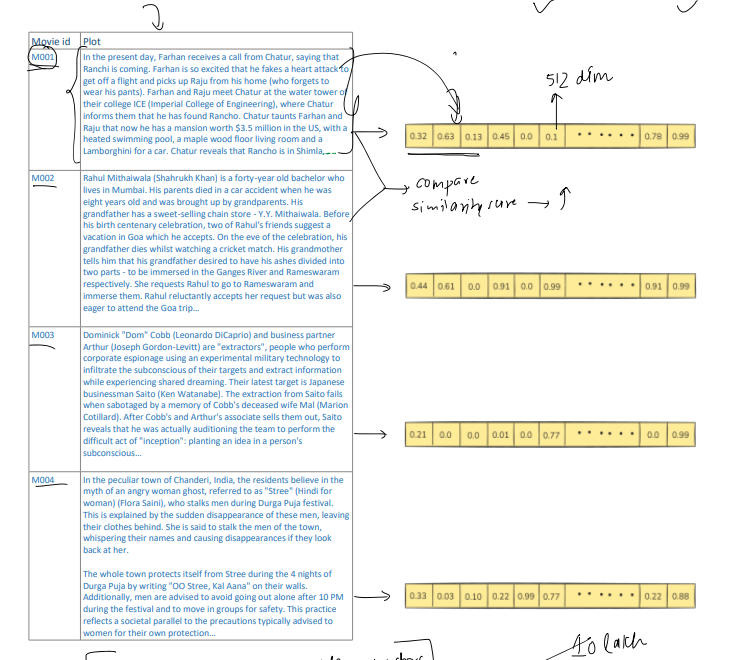

### Problems with this System
1. Generating embeddings for a large number of movies is resource-intensive.  
2. Relational databases are inefficient for storing and searching high-dimensional vectors.  
3. Semantic search requires specialized vector stores for fast similarity queries.

## Vector Store

A vector store is a system designed to store and retrieve data represented as numerical vectors.

### Key Features

1. **Storage** – Stores vectors along with their metadata, either in-memory for fast access or on-disk for durability and large-scale applications.
    - Metadata: MovieID, MovieName

3. **Similarity Search** – Retrieves vectors that are most similar to a given query vector using distance metrics like cosine similarity or Euclidean distance.  

4. **Indexing** – Uses specialized data structures (e.g., approximate nearest neighbor algorithms) to enable fast searches in high-dimensional vector spaces.

5. **CRUD Operations** – Supports Create, Read, Update, and Delete operations to manage the lifecycle of stored vectors.  

### Use Cases

1. Semantic Search  
2. RAG (Retrieval-Augmented Generation)  
3. Recommender Systems  
4. Image / Multimedia Search

## Vector Store vs Vector Database

### Vector Store: Storage + Retrieval
- A lightweight library or service focused mainly on storing embeddings and performing similarity search.  
- May not include traditional database features like transactions, rich query languages, or role-based access control.  
- Ideal for prototyping and smaller-scale applications.  
- Example: **FAISS** (handles vector similarity search, but persistence and scaling are managed separately).

---

### Vector Database: Vector Store + Database Capability
- A full-fledged database system designed specifically to store and query vectors.  
- Provides additional database-like features such as:
  - Distributed architecture for horizontal scaling  
  - Durability and persistence (replication, backup/restore)  
  - Metadata handling (schemas, filtering)  
  - ACID or near-ACID guarantees  
  - Authentication, authorization, and enhanced security  
- Designed for production environments with large-scale datasets.  
- Examples: **Milvus**, **Qdrant**, **Weaviate**  

---

### Summary
A **vector database** is essentially a **vector store with advanced database capabilities** like clustering, scaling, security, metadata filtering, and durability.

## Vector Stores in LangChain

- **Supported Stores** – LangChain integrates with multiple vector stores such as FAISS, Pinecone, Chroma, Qdrant, and Weaviate, providing flexibility in terms of scalability, features, and deployment options.  

- **Common Interface** – LangChain provides a uniform Vector Store API, allowing you to switch from one backend (e.g., FAISS) to another (e.g., Pinecone) with minimal code changes.  

- **Metadata Handling** – Most vector stores in LangChain support attaching metadata (e.g., timestamps, authors, categories) to documents, enabling filtered and more precise retrieval.

## Chroma Vector Database

Chroma is a lightweight, open-source vector database designed for storing and retrieving embeddings efficiently. It is especially well-suited for local development and small- to medium-scale production applications, offering easy setup, built-in persistence, and seamless integration with frameworks like LangChain.
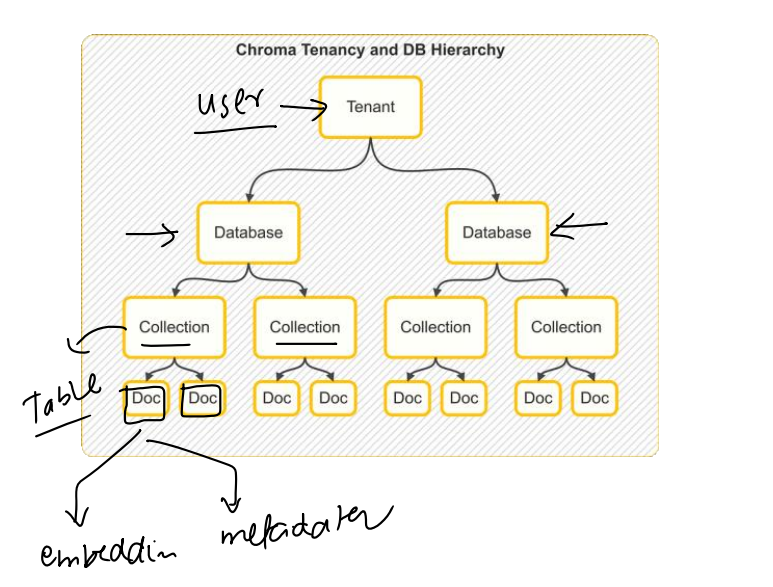

In [27]:
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
load_dotenv()

True

In [28]:
from langchain_core.documents import Document

# Create 10 IPL-related Document objects (MI & CSK players)

doc1 = Document(
    page_content="Mumbai Indians captain Rohit Sharma is known for his elegant batting and leadership in the IPL.",
    metadata={"team": "Mumbai Indians", "player": "Rohit Sharma"}
)

doc2 = Document(
    page_content="Jasprit Bumrah is a key fast bowler for Mumbai Indians, famous for his deadly yorkers.",
    metadata={"team": "Mumbai Indians", "player": "Jasprit Bumrah"}
)

doc3 = Document(
    page_content="Suryakumar Yadav plays aggressive and innovative shots for Mumbai Indians in the middle order.",
    metadata={"team": "Mumbai Indians", "player": "Suryakumar Yadav"}
)

doc4 = Document(
    page_content="Hardik Pandya is an all-rounder for Mumbai Indians, contributing with both bat and ball.",
    metadata={"team": "Mumbai Indians", "player": "Hardik Pandya"}
)

doc5 = Document(
    page_content="Ishan Kishan is a wicketkeeper-batsman for Mumbai Indians known for explosive starts.",
    metadata={"team": "Mumbai Indians", "player": "Ishan Kishan"}
)

doc6 = Document(
    page_content="MS Dhoni, captain of Chennai Super Kings, is admired for his calm leadership and finishing abilities.",
    metadata={"team": "Chennai Super Kings", "player": "MS Dhoni"}
)

doc7 = Document(
    page_content="Ravindra Jadeja is a star all-rounder for Chennai Super Kings, contributing with bat, ball, and fielding.",
    metadata={"team": "Chennai Super Kings", "player": "Ravindra Jadeja"}
)

doc8 = Document(
    page_content="Ruturaj Gaikwad is a top-order batsman for Chennai Super Kings known for his consistency.",
    metadata={"team": "Chennai Super Kings", "player": "Ruturaj Gaikwad"}
)

doc9 = Document(
    page_content="Deepak Chahar is a swing bowler for Chennai Super Kings who often takes early wickets.",
    metadata={"team": "Chennai Super Kings", "player": "Deepak Chahar"}
)

doc10 = Document(
    page_content="Moeen Ali provides balance to Chennai Super Kings with his all-round performance.",
    metadata={"team": "Chennai Super Kings", "player": "Moeen Ali"}
)

docs = [doc1, doc2, doc3, doc4, doc5, doc6, doc7, doc8, doc9, doc10]


In [30]:
vector_store = Chroma(
    embedding_function=OpenAIEmbeddings(),
    persist_directory='chroma_db',
    collection_name='sample'
)
vector_store.persist()

/tmp/ipykernel_2371/1577326406.py:6: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vector_store.persist()


In [31]:
vector_store.add_documents(docs)

['11be1d88-50e1-4aa1-ba85-f90e1f4c6e63',
 '5677c1cb-9ef2-4270-a13e-b9cc23c02149',
 '46f75777-7a4b-4412-ab16-c9596e8aa879',
 '36ae76f6-74bb-4ec0-a3bd-5bb9d4fefa41',
 '1abf2d4f-1c47-4622-9343-8788e8c3f2a2',
 '2ec0337f-8755-4bd8-9201-d2770f86d231',
 '7bb10c9b-b2de-48bd-9953-98a0aa25ac9c',
 '5fc4f22c-4f2d-41c0-a697-e35374469033',
 'dfe61adb-d000-4f41-91d7-f1935b2d040e',
 'e534a889-087f-4552-86ec-8e04eb1d055d']

In [15]:
vector_store.get(include=["embeddings","documents","metadatas"])

{'ids': ['4b4d04e4-be9e-47e3-a5ac-ead25f28ad59',
  '929d75c8-fe46-49e7-9fdb-4cea6add1a30',
  '81def3e0-ea95-4743-8001-87598c5f69bf',
  'beb32f15-5bc4-4b5f-9f88-ee905283c028',
  'f8ea76e5-90de-439b-abea-2e73a68e986c',
  '5c002564-f76a-46ba-b0db-2b568d381434',
  '16fdc350-45d2-488a-b721-00e618bac9b4',
  '5e137b2f-a970-4e78-99bf-05f3c9fc90d8',
  'fe76beb8-9607-4832-93c2-31f532d80662',
  'be4c86bd-25df-4043-abfd-2fa0ef98004d',
  '42530e2f-f943-4013-a5c7-4c08ee84f544',
  'edb543f6-574a-4503-9052-9647b82a90b6',
  '8971da14-942c-47bd-8bb0-6a85c65a140a',
  '2a9c5a53-3d20-4739-a5d3-827c901e86d4'],
 'embeddings': array([[-0.00717699,  0.00095768,  0.01234621, ..., -0.01560327,
          0.00314232, -0.02293323],
        [-0.00598655, -0.01749005,  0.00699726, ...,  0.021309  ,
         -0.01776372, -0.02287639],
        [-0.02965685, -0.00992917,  0.01027538, ...,  0.00282361,
         -0.02529325, -0.01464552],
        ...,
        [ 0.00357111,  0.0157391 ,  0.0233531 , ..., -0.01876635,
     

In [16]:
vector_store.similarity_search(
    query="What is Cricket",
    k=1
)

[Document(metadata={'topic': 'cricket', 'source': 'sports_article'}, page_content='Cricket is a popular sport played worldwide.')]

In [17]:
vector_store.similarity_search_with_score(
    query="What is Cricket",
    k=1
)

[(Document(metadata={'topic': 'cricket', 'source': 'sports_article'}, page_content='Cricket is a popular sport played worldwide.'),
  0.21651630103588104)]

In [18]:
# MetaData Filtering
vector_store.similarity_search_with_score(
    query="",
    filter={"team":"Chennai Super Kings"}
)

[(Document(metadata={'team': 'Chennai Super Kings', 'player': 'Moeen Ali'}, page_content='Moeen Ali provides balance to Chennai Super Kings with his all-round performance.'),
  0.6280561685562134),
 (Document(metadata={'player': 'Deepak Chahar', 'team': 'Chennai Super Kings'}, page_content='Deepak Chahar is a swing bowler for Chennai Super Kings who often takes early wickets.'),
  0.6315021514892578),
 (Document(metadata={'team': 'Chennai Super Kings', 'player': 'Ravindra Jadeja'}, page_content='Ravindra Jadeja is a star all-rounder for Chennai Super Kings, contributing with bat, ball, and fielding.'),
  0.6343179941177368),
 (Document(metadata={'team': 'Chennai Super Kings', 'player': 'Ruturaj Gaikwad'}, page_content='Ruturaj Gaikwad is a top-order batsman for Chennai Super Kings known for his consistency.'),
  0.6409722566604614)]

In [19]:
# Update Documents
doc11 = Document(
    page_content="MS Dhoni is one of the most successful captains in IPL history, known for his sharp cricketing mind, exceptional wicketkeeping skills, and ability to finish matches under pressure for Chennai Super Kings.",
    metadata={"team": "Chennai Super Kings", "player": "MS Dhoni", "role": "Captain & Wicketkeeper"}
)
vector_store.update_document(document_id="be4c86bd-25df-4043-abfd-2fa0ef98004d", document=doc11)

In [21]:
vector_store.get(include=['embeddings','documents','metadatas'])

{'ids': ['4b4d04e4-be9e-47e3-a5ac-ead25f28ad59',
  '929d75c8-fe46-49e7-9fdb-4cea6add1a30',
  '81def3e0-ea95-4743-8001-87598c5f69bf',
  'beb32f15-5bc4-4b5f-9f88-ee905283c028',
  'f8ea76e5-90de-439b-abea-2e73a68e986c',
  '5c002564-f76a-46ba-b0db-2b568d381434',
  '16fdc350-45d2-488a-b721-00e618bac9b4',
  '5e137b2f-a970-4e78-99bf-05f3c9fc90d8',
  'fe76beb8-9607-4832-93c2-31f532d80662',
  'be4c86bd-25df-4043-abfd-2fa0ef98004d',
  '42530e2f-f943-4013-a5c7-4c08ee84f544',
  'edb543f6-574a-4503-9052-9647b82a90b6',
  '8971da14-942c-47bd-8bb0-6a85c65a140a',
  '2a9c5a53-3d20-4739-a5d3-827c901e86d4'],
 'embeddings': array([[-0.00717699,  0.00095768,  0.01234621, ..., -0.01560327,
          0.00314232, -0.02293323],
        [-0.00598655, -0.01749005,  0.00699726, ...,  0.021309  ,
         -0.01776372, -0.02287639],
        [-0.02965685, -0.00992917,  0.01027538, ...,  0.00282361,
         -0.02529325, -0.01464552],
        ...,
        [ 0.00357111,  0.0157391 ,  0.0233531 , ..., -0.01876635,
     

In [22]:
vector_store.delete(ids=['929d75c8-fe46-49e7-9fdb-4cea6add1a30'])
vector_store.get(include=['embeddings','documents','metadatas'])

{'ids': ['4b4d04e4-be9e-47e3-a5ac-ead25f28ad59',
  '81def3e0-ea95-4743-8001-87598c5f69bf',
  'beb32f15-5bc4-4b5f-9f88-ee905283c028',
  'f8ea76e5-90de-439b-abea-2e73a68e986c',
  '5c002564-f76a-46ba-b0db-2b568d381434',
  '16fdc350-45d2-488a-b721-00e618bac9b4',
  '5e137b2f-a970-4e78-99bf-05f3c9fc90d8',
  'fe76beb8-9607-4832-93c2-31f532d80662',
  'be4c86bd-25df-4043-abfd-2fa0ef98004d',
  '42530e2f-f943-4013-a5c7-4c08ee84f544',
  'edb543f6-574a-4503-9052-9647b82a90b6',
  '8971da14-942c-47bd-8bb0-6a85c65a140a',
  '2a9c5a53-3d20-4739-a5d3-827c901e86d4'],
 'embeddings': array([[-0.00717699,  0.00095768,  0.01234621, ..., -0.01560327,
          0.00314232, -0.02293323],
        [-0.02965685, -0.00992917,  0.01027538, ...,  0.00282361,
         -0.02529325, -0.01464552],
        [-0.00799298, -0.00811515,  0.01062944, ...,  0.00504143,
         -0.01016645, -0.02914253],
        ...,
        [ 0.00357111,  0.0157391 ,  0.0233531 , ..., -0.01876635,
          0.0165254 , -0.0120697 ],
        [ 0